In [1]:
%pip install numpy pandas matplotlib seaborn torch

  Using cached torch-2.10.0-2-cp313-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached filelock-3.24.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.10.0-2-cp313-none-macosx_11_0_arm64.whl (79.5 MB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached filelock-3.24.3-py3-none-any.whl (24 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (13

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [14]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
     device = torch.device("mps:0")

# x = torch.linspace(-10, 10, 20000, dtype=torch.float16, device=device)
# y = torch.linspace(-10, 10, 20000, dtype=torch.float16, device=device)

torch.manual_seed(42)
x = torch.empty(20000, device=device).uniform_(-10, 10)
y = torch.empty(20000, device=device).uniform_(-10, 10)

In [11]:
def target_function(x, y):
    """sin(x + 2*y) * exp(-(2*x + y)^2)"""
    return torch.sin(x + 2*y) * torch.exp(-(2*x + y)**2)

In [15]:
z = target_function(x, y)

In [18]:
xy = torch.column_stack([x, y])
z = z.view(-1, 1)


In [24]:
from torch.utils.data import TensorDataset, random_split

dataset = TensorDataset(xy, z)
train_data, val_data, test_data = random_split(
    dataset, [0.7, 0.15, 0.15]
)

X_train = train_data.dataset.tensors[0][train_data.indices]
z_train = train_data.dataset.tensors[1][train_data.indices]

X_val = val_data.dataset.tensors[0][val_data.indices]
z_val = val_data.dataset.tensors[1][val_data.indices]

X_test = test_data.dataset.tensors[0][test_data.indices]
z_test = test_data.dataset.tensors[1][test_data.indices]


In [39]:
class RegressionNet(nn.Module):
    def __init__(self, n_hidden_neurons):
        super().__init__()
        self.fc1 = nn.Linear(2, n_hidden_neurons)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(n_hidden_neurons, n_hidden_neurons)
        self.act2 = nn.Tanh()
        self.fc3 = nn.Linear(n_hidden_neurons, 1)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        return x

In [68]:
torch.manual_seed(42)
model = RegressionNet(128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 8000
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

In [69]:
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train)
    loss_train = criterion(pred_train, z_train)
    loss_train.backward()
    optimizer.step()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        pred_val = model(X_val)
        loss_val = criterion(pred_val, z_val)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {loss_train.item():.6f} | Val Loss: {loss_val.item():.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch  100 | Train Loss: 0.016716 | Val Loss: 0.015027 | LR: 0.001000
Epoch  200 | Train Loss: 0.016213 | Val Loss: 0.014676 | LR: 0.000998
Epoch  300 | Train Loss: 0.015731 | Val Loss: 0.014370 | LR: 0.000997
Epoch  400 | Train Loss: 0.015169 | Val Loss: 0.013991 | LR: 0.000994
Epoch  500 | Train Loss: 0.014599 | Val Loss: 0.013555 | LR: 0.000990
Epoch  600 | Train Loss: 0.014031 | Val Loss: 0.013070 | LR: 0.000986
Epoch  700 | Train Loss: 0.013452 | Val Loss: 0.012540 | LR: 0.000981
Epoch  800 | Train Loss: 0.012931 | Val Loss: 0.012072 | LR: 0.000976
Epoch  900 | Train Loss: 0.012495 | Val Loss: 0.011663 | LR: 0.000969
Epoch 1000 | Train Loss: 0.012131 | Val Loss: 0.011595 | LR: 0.000962
Epoch 1100 | Train Loss: 0.011729 | Val Loss: 0.010963 | LR: 0.000954
Epoch 1200 | Train Loss: 0.012616 | Val Loss: 0.012878 | LR: 0.000946
Epoch 1300 | Train Loss: 0.010981 | Val Loss: 0.010286 | LR: 0.000936
Epoch 1400 | Train Loss: 0.010567 | Val Loss: 0.009919 | LR: 0.000926
Epoch 1500 | Train L

In [71]:
print("Baseline MSE: ", criterion(torch.zeros_like(z_val), z_val).item())

Baseline MSE:  0.015522759407758713


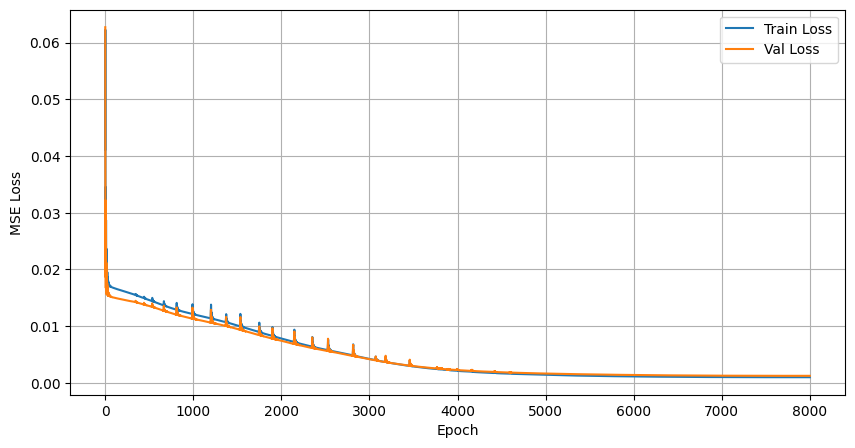

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test)
    loss_test = criterion(pred_test, z_test)

print(f"Baseline MSE: {criterion(torch.zeros_like(z_val), z_val).item():.6f}")
print(f"Test MSE: {loss_test.item():.6f}")

Baseline MSE: 0.015523
Test MSE: 0.001214


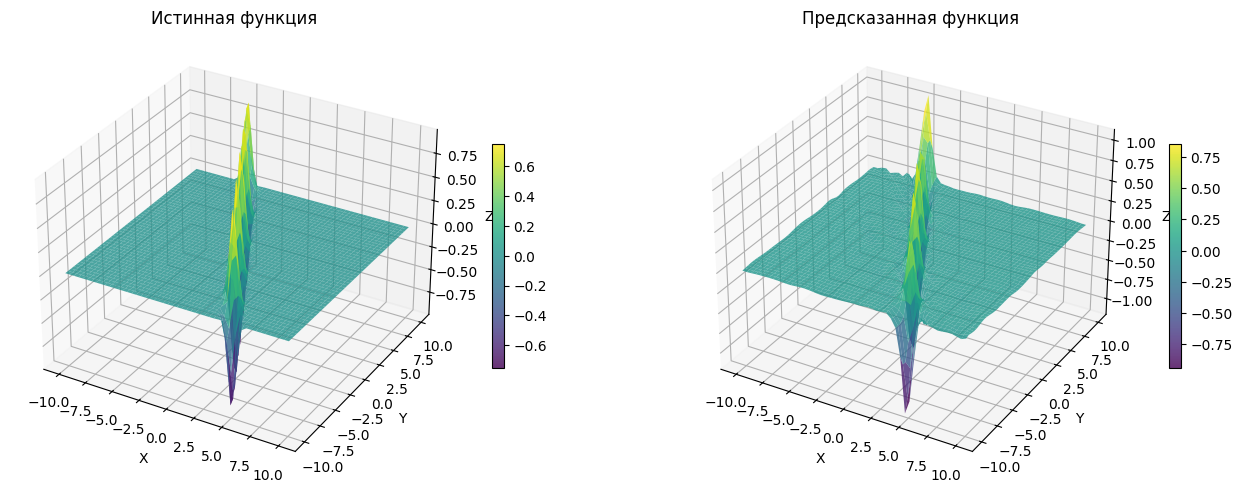

In [78]:
grid_size = 50
x_grid = torch.linspace(-10, 10, grid_size, device=device)
y_grid = torch.linspace(-10, 10, grid_size, device=device)
X_grid, Y_grid = torch.meshgrid(x_grid, y_grid, indexing='ij')

# Истинные значения
Z_true = target_function(X_grid, Y_grid).cpu().numpy()

# Предсказания модели
grid_tensor = torch.column_stack([X_grid.ravel(), Y_grid.ravel()])

model.eval()
with torch.no_grad():
    Z_pred = model(grid_tensor).cpu().numpy().reshape(grid_size, grid_size)

X_np = X_grid.cpu().numpy()
Y_np = Y_grid.cpu().numpy()

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, Z_true, cmap='viridis', alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Истинная функция')
plt.colorbar(surf1, ax=ax1, shrink=0.5)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, Z_pred, cmap='viridis', alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Предсказанная функция')
plt.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

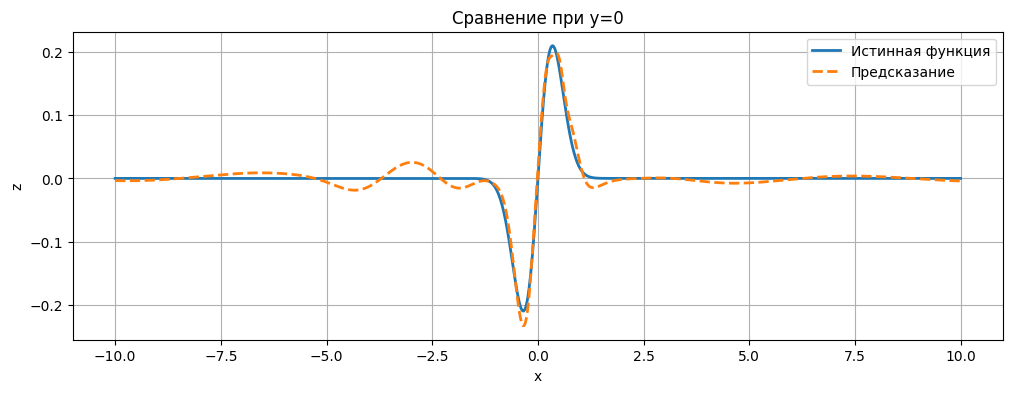

In [81]:
x_line = torch.linspace(-10, 10, 1000, device=device)
y_fixed = torch.zeros(1000, device=device)

z_true_line = target_function(x_line, y_fixed).cpu().numpy()

model.eval()
with torch.no_grad():
    z_pred_line = model(torch.column_stack([x_line, y_fixed])).cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(x_line.cpu().numpy(), z_true_line, label='Истинная функция', linewidth=2)
plt.plot(x_line.cpu().numpy(), z_pred_line, label='Предсказание', linewidth=2, linestyle='--')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Сравнение при y=0')
plt.legend()
plt.grid(True)
plt.show()